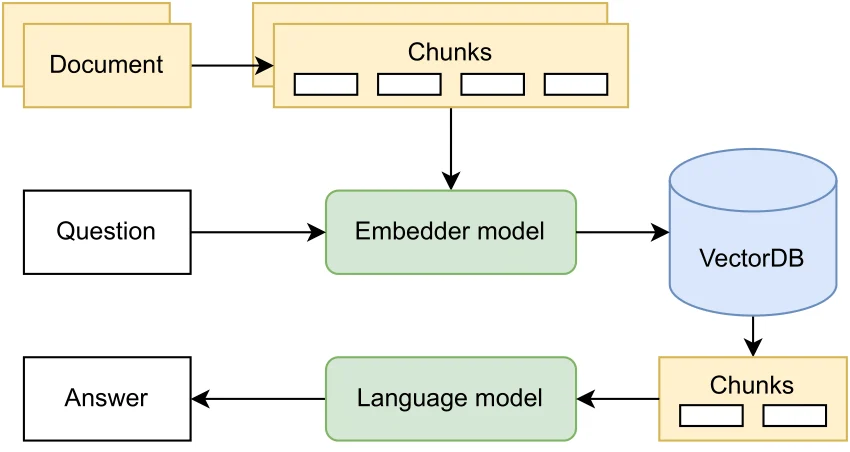

1. What is RAG?

RAG (Retrieval-Augmented Generation) is a technique where an LLM retrieves external knowledge before generating an answer.

3. Complete RAG Pipeline
. RAG Pipeline Flow

Typical retrieval pipeline:

1.Load documents

2.Split into chunks

3.Convert chunks to embeddings

4.Store in vector database

5.User asks question

Convert question → embedding

Retrieve most similar chunks

Send to LLM for final answer


Document Loaders: LangChain offers document loaders to ingest data from various sources (PDFs, websites, databases, etc.).

Text Splitters: It includes tools for splitting large documents into smaller, semantically meaningful chunks, which is crucial for efficient retrieval and fitting within the LLM's context window.

Embeddings & Vector Stores: LangChain simplifies the process of converting text chunks into vector embeddings using various models and storing them in a vector database (e.g., Chroma, FAISS, Pinecone) for efficient semantic search.

Retrievers: It provides abstractions for different retrieval strategies, including vector store-based, multi-query, and self-query retrievers, to fetch the most relevant context based on a user's query.

Chains & Agents: The framework allows developers to chain these components together into a complete RAG workflow. Agents can use LLMs to reason and decide when and how to use retrieval tools dynamically, enabling more complex, multi-step interactions. 

Common RAG Architectures in LangChain

2-Step RAG Chain: A linear process where retrieval is followed immediately by generation. It is predictable and fast for simple queries.

Agentic RAG: Uses an LLM agent to decide when and how to retrieve information. It can use multiple tools and refine searches iteratively for complex tasks.

Hybrid RAG: Combines semantic vector search with keyword-based search to improve precision for specific terms or names.

Advanced RAG: Incorporates techniques like re-ranking (using a more powerful model to sort the top retrieved results) and query expansion to improve accuracy. 

Document Loaders

Category 	      Examples

1.Unstructured	 PDFs, Word Docs, Text files, Markdown, Blogs

2.Semi-Structured	 JSON, XML, HTML, Email logs

3.Structured	     CSV, SQL Database records, Excel sheets

4.Multimedia	     Audio/Video transcripts, Images (via OCR)



document loader link 

https://docs.langchain.com/oss/python/integrations/document_loaders

2 # Chunking

1️⃣ What is Chunking?

Chunking is the process of splitting large text into smaller pieces (chunks) before generating embeddings.

Large documents cannot be processed directly by LLMs or embedding models because of token limits.



Types of Chunking


1- Text structure-based   -  RecursiveCharacterTextSplitter

2- token based

3- Document structure-based


In [ ]:
# 1️⃣ Character-based Chunking

# Split by characters.

# Example tool:

# RecursiveCharacterTextSplitter


from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

loader = TextLoader(r"doc/data.txt")
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=50,
    length_function=len,
    is_separator_regex=False,
)

chunks = splitter.split_documents(docs)
type(chunks)

list

Let’s go through the parameters set above for RecursiveCharacterTextSplitter:

chunk_size: The maximum size of a chunk, where size is determined by the length_function.

chunk_overlap: Target overlap between chunks. Overlapping chunks helps to mitigate loss of information when context is divided between chunks.

length_function: Function determining the chunk size.

is_separator_regex: Whether the separator list (defaulting to ["\n\n", "\n", " ", ""]) should be interpreted as regex.

# 2.Length-based


 split documents based on their length. This simple yet effective approach ensures that each chunk doesn’t exceed a specified size limit

Types of length-based splitting:
Token-based: Splits text based on the number of tokens, which is useful when working with language models.

Character-based: Splits text based on the number of characters, which can be more consistent across different types of text.

from langchain_text_splitters import CharacterTextSplitter

text_splitter = CharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base", chunk_size=100, chunk_overlap=0
)
texts = text_splitter.split_text(document)

token based - 
https://docs.langchain.com/oss/python/integrations/splitters/split_by_token#sentencetransformers

Language models have a token limit. You should not exceed the token limit. When you split your text into chunks it is therefore a good idea to count the number of tokens

###  Splitting by character

Character-based splitting is the simplest approach to text splitting. It divides text using a specified character sequence (default: "\n\n"), with chunk length measured by the number of characters.


.split_text — returns plain string chunks.

.create_documents — returns LangChain Document objects, useful when metadata needs to be preserved for downstream tasks.

In [ ]:
from langchain_text_splitters import CharacterTextSplitter

# Load an example document
with open("state_of_the_union.txt") as f:
    state_of_the_union = f.read()

text_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    is_separator_regex=False,
)
texts = text_splitter.create_documents([state_of_the_union])
texts

Created a chunk of size 1163, which is longer than the specified 1000
Created a chunk of size 1015, which is longer than the specified 1000


[Document(metadata={}, page_content='Madame Speaker, Vice President Biden, members of Congress, distinguished guests, and fellow Americans:\n\nOur Constitution declares that from time to time, the president shall give to Congress information about the state of our union. For 220 years, our leaders have fulfilled this duty. They have done so during periods of prosperity and tranquility. And they have done so in the midst of war and depression; at moments of great strife and great struggle.'),
 Document(metadata={}, page_content="It's tempting to look back on these moments and assume that our progress was inevitable, that America was always destined to succeed. But when the Union was turned back at Bull Run and the Allies first landed at Omaha Beach, victory was very much in doubt. When the market crashed on Black Tuesday and civil rights marchers were beaten on Bloody Sunday, the future was anything but certain. These were times that tested the courage of our convictions and the strengt

In [15]:
print(texts[0])

page_content='Madame Speaker, Vice President Biden, members of Congress, distinguished guests, and fellow Americans:

Our Constitution declares that from time to time, the president shall give to Congress information about the state of our union. For 220 years, our leaders have fulfilled this duty. They have done so during periods of prosperity and tranquility. And they have done so in the midst of war and depression; at moments of great strife and great struggle.'


 # 3 Document structure-based

 HTML, Markdown, or JSON files.
 
 link :https://docs.langchain.com/oss/python/integrations/splitters